In [82]:
!pip install shap xgboost imbalanced-learn

In [83]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import shap

In [84]:
import pandas as pd
df = pd.read_csv('insurance_claims.csv')

In [85]:
df.shape

(1000, 40)

In [86]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [87]:
df.tail()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN
999,456,60,556080,1996-11-11,OH,250/500,1000,766.19,0,612260,...,?,5060,460,920,3680,Mercedes,E400,2007,N,NaN


In [88]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')

In [89]:
df.dtypes

,0
months_as_customer,int64
age,int64
policy_number,int64
policy_bind_date,object
policy_state,object
policy_csl,object
policy_deductable,int64
policy_annual_premium,float64
umbrella_limit,int64
insured_zip,int64


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [91]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [92]:
df.isnull().sum()

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
print("Dataset Shape:", df.shape)
print("Number of Columns:", len(df.columns))
print("Missing Values:\n")
print(df.isnull().sum())

Dataset Shape: (1000, 40)
Number of Columns: 40
Missing Values:

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0

In [95]:
df.columns.tolist()

['months_as_customer',
 'age',
 'policy_number',
 'policy_bind_date',
 'policy_state',
 'policy_csl',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'capital-gains',
 'capital-loss',
 'incident_date',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'property_damage',
 'bodily_injuries',
 'witnesses',
 'police_report_available',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_make',
 'auto_model',
 'auto_year',
 'fraud_reported',
 '_c39']

In [96]:
(df == '?').sum()

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [97]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [98]:
print("Numerical Columns")
print(numerical_cols)

print()

print("Categorical Columns")
print(categorical_cols)

Numerical Columns
Index(['months_as_customer', 'age', 'policy_number', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip',
       'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim',
       'auto_year', '_c39'],
      dtype='object')

Categorical Columns
Index(['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_city', 'incident_location',
       'property_damage', 'police_report_available', 'auto_make', 'auto_model',
       'fraud_reported'],
      dtype='object')


In [99]:
df['fraud_reported'].value_counts()

,count
fraud_reported,
N,753
Y,247


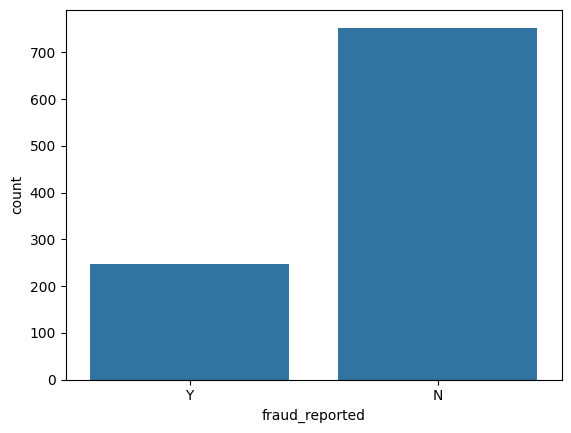

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='fraud_reported', data=df)
plt.show()

In [101]:
df.drop('_c39', axis=1, inplace=True)

In [102]:
import numpy as np

df.replace('?', np.nan, inplace=True)

In [103]:
df.duplicated().sum()

np.int64(0)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [105]:
df['fraud_reported'] = df['fraud_reported'].map({
    'Y':1,
    'N':0
})

In [106]:
df['fraud_reported'].value_counts()

,count
fraud_reported,
0,753
1,247


In [107]:
df[['policy_bind_date', 'incident_date']].head()

,policy_bind_date,incident_date
0,2014-10-17,2015-01-25
1,2006-06-27,2015-01-21
2,2000-09-06,2015-02-22
3,1990-05-25,2015-01-10
4,2014-06-06,2015-02-17


In [108]:
df['policy_bind_date'] = pd.to_datetime(
    df['policy_bind_date']
)

df['incident_date'] = pd.to_datetime(
    df['incident_date']
)

In [109]:
df.shape

(1000, 39)

In [110]:
df.isnull().sum()

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [111]:
for col in ['collision_type',
            'authorities_contacted',
            'property_damage',
            'police_report_available']:
    print(col)
    print(df[col].mode())
    print()

collision_type
0    Rear Collision
Name: collision_type, dtype: object

authorities_contacted
0    Police
Name: authorities_contacted, dtype: object

property_damage
0    NO
Name: property_damage, dtype: object

police_report_available
0    NO
Name: police_report_available, dtype: object



In [112]:
for col in ['collision_type',
            'authorities_contacted',
            'property_damage',
            'police_report_available']:

    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

In [113]:
df.isnull().sum()

,0
months_as_customer,0
age,0
policy_number,0
policy_bind_date,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0


In [114]:
df['policy_bind_year'] = df['policy_bind_date'].dt.year

In [115]:
df[['policy_bind_date', 'policy_bind_year']].head()

,policy_bind_date,policy_bind_year
0,2014-10-17,2014
1,2006-06-27,2006
2,2000-09-06,2000
3,1990-05-25,1990
4,2014-06-06,2014


In [116]:
df['policy_bind_month'] = df['policy_bind_date'].dt.month

In [117]:
df['incident_year'] = df['incident_date'].dt.year

In [118]:
df['incident_month'] = df['incident_date'].dt.month

In [119]:
df['policy_duration_days'] = (
    df['incident_date']
    - df['policy_bind_date']
).dt.days

In [120]:
df[['policy_bind_date',
    'incident_date',
    'policy_duration_days']].head()

,policy_bind_date,incident_date,policy_duration_days
0,2014-10-17,2015-01-25,100
1,2006-06-27,2015-01-21,3130
2,2000-09-06,2015-02-22,5282
3,1990-05-25,2015-01-10,8996
4,2014-06-06,2015-02-17,256


In [121]:
df.drop(
    ['policy_bind_date', 'incident_date'],
    axis=1,
    inplace=True
)

In [122]:
df.shape

(1000, 42)

In [123]:
df.head()

,months_as_customer,age,policy_number,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,...,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,policy_bind_year,policy_bind_month,incident_year,incident_month,policy_duration_days
0,328,48,521585,OH,250/500,1000,1406.91,0,466132,MALE,...,52080,Saab,92x,2004,1,2014,10,2015,1,100
1,228,42,342868,IN,250/500,2000,1197.22,5000000,468176,MALE,...,3510,Mercedes,E400,2007,1,2006,6,2015,1,3130
2,134,29,687698,OH,100/300,2000,1413.14,5000000,430632,FEMALE,...,23100,Dodge,RAM,2007,0,2000,9,2015,2,5282
3,256,41,227811,IL,250/500,2000,1415.74,6000000,608117,FEMALE,...,50720,Chevrolet,Tahoe,2014,1,1990,5,2015,1,8996
4,228,44,367455,IL,500/1000,1000,1583.91,6000000,610706,MALE,...,4550,Accura,RSX,2009,0,2014,6,2015,2,256


In [124]:
for col in ['policy_number',
            'insured_zip',
            'incident_location']:
    print(col, ":", col in df.columns)

policy_number : True
insured_zip : True
incident_location : True


In [125]:
categorical_cols = df.select_dtypes(include='object').columns

print("Number of categorical columns:", len(categorical_cols))
print(categorical_cols)

Number of categorical columns: 18
Index(['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'insured_relationship',
       'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'property_damage', 'police_report_available',
       'auto_make', 'auto_model'],
      dtype='object')


In [126]:
from sklearn.preprocessing import LabelEncoder

In [127]:
le = LabelEncoder()

In [128]:
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [129]:
df.head()

,months_as_customer,age,policy_number,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,...,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,policy_bind_year,policy_bind_month,incident_year,incident_month,policy_duration_days
0,328,48,521585,2,1,1000,1406.91,0,466132,1,...,52080,10,1,2004,1,2014,10,2015,1,100
1,228,42,342868,1,1,2000,1197.22,5000000,468176,1,...,3510,8,12,2007,1,2006,6,2015,1,3130
2,134,29,687698,2,0,2000,1413.14,5000000,430632,0,...,23100,4,30,2007,0,2000,9,2015,2,5282
3,256,41,227811,0,1,2000,1415.74,6000000,608117,0,...,50720,3,34,2014,1,1990,5,2015,1,8996
4,228,44,367455,0,2,1000,1583.91,6000000,610706,1,...,4550,0,31,2009,0,2014,6,2015,2,256


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_state                 1000 non-null   int64  
 4   policy_csl                   1000 non-null   int64  
 5   policy_deductable            1000 non-null   int64  
 6   policy_annual_premium        1000 non-null   float64
 7   umbrella_limit               1000 non-null   int64  
 8   insured_zip                  1000 non-null   int64  
 9   insured_sex                  1000 non-null   int64  
 10  insured_education_level      1000 non-null   int64  
 11  insured_occupation           1000 non-null   int64  
 12  insured_hobbies              1000 non-null   int64  
 13  insured_relationshi

In [131]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

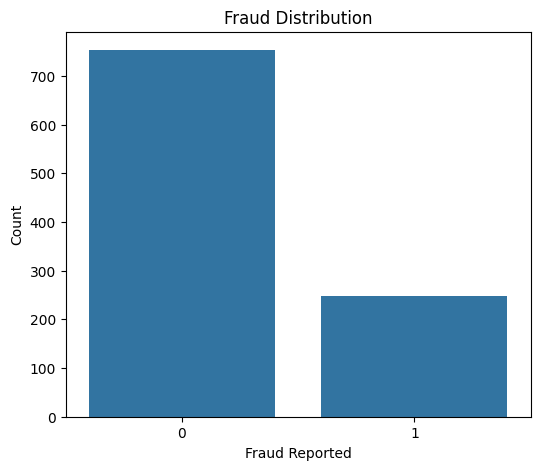

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.countplot(
    x='fraud_reported',
    data=df
)

plt.title('Fraud Distribution')
plt.xlabel('Fraud Reported')
plt.ylabel('Count')

plt.show()

In [133]:
fraud_percentage = (
    df['fraud_reported']
    .value_counts(normalize=True)
    * 100
)

print(fraud_percentage)

fraud_reported
0    75.3
1    24.7
Name: proportion, dtype: float64


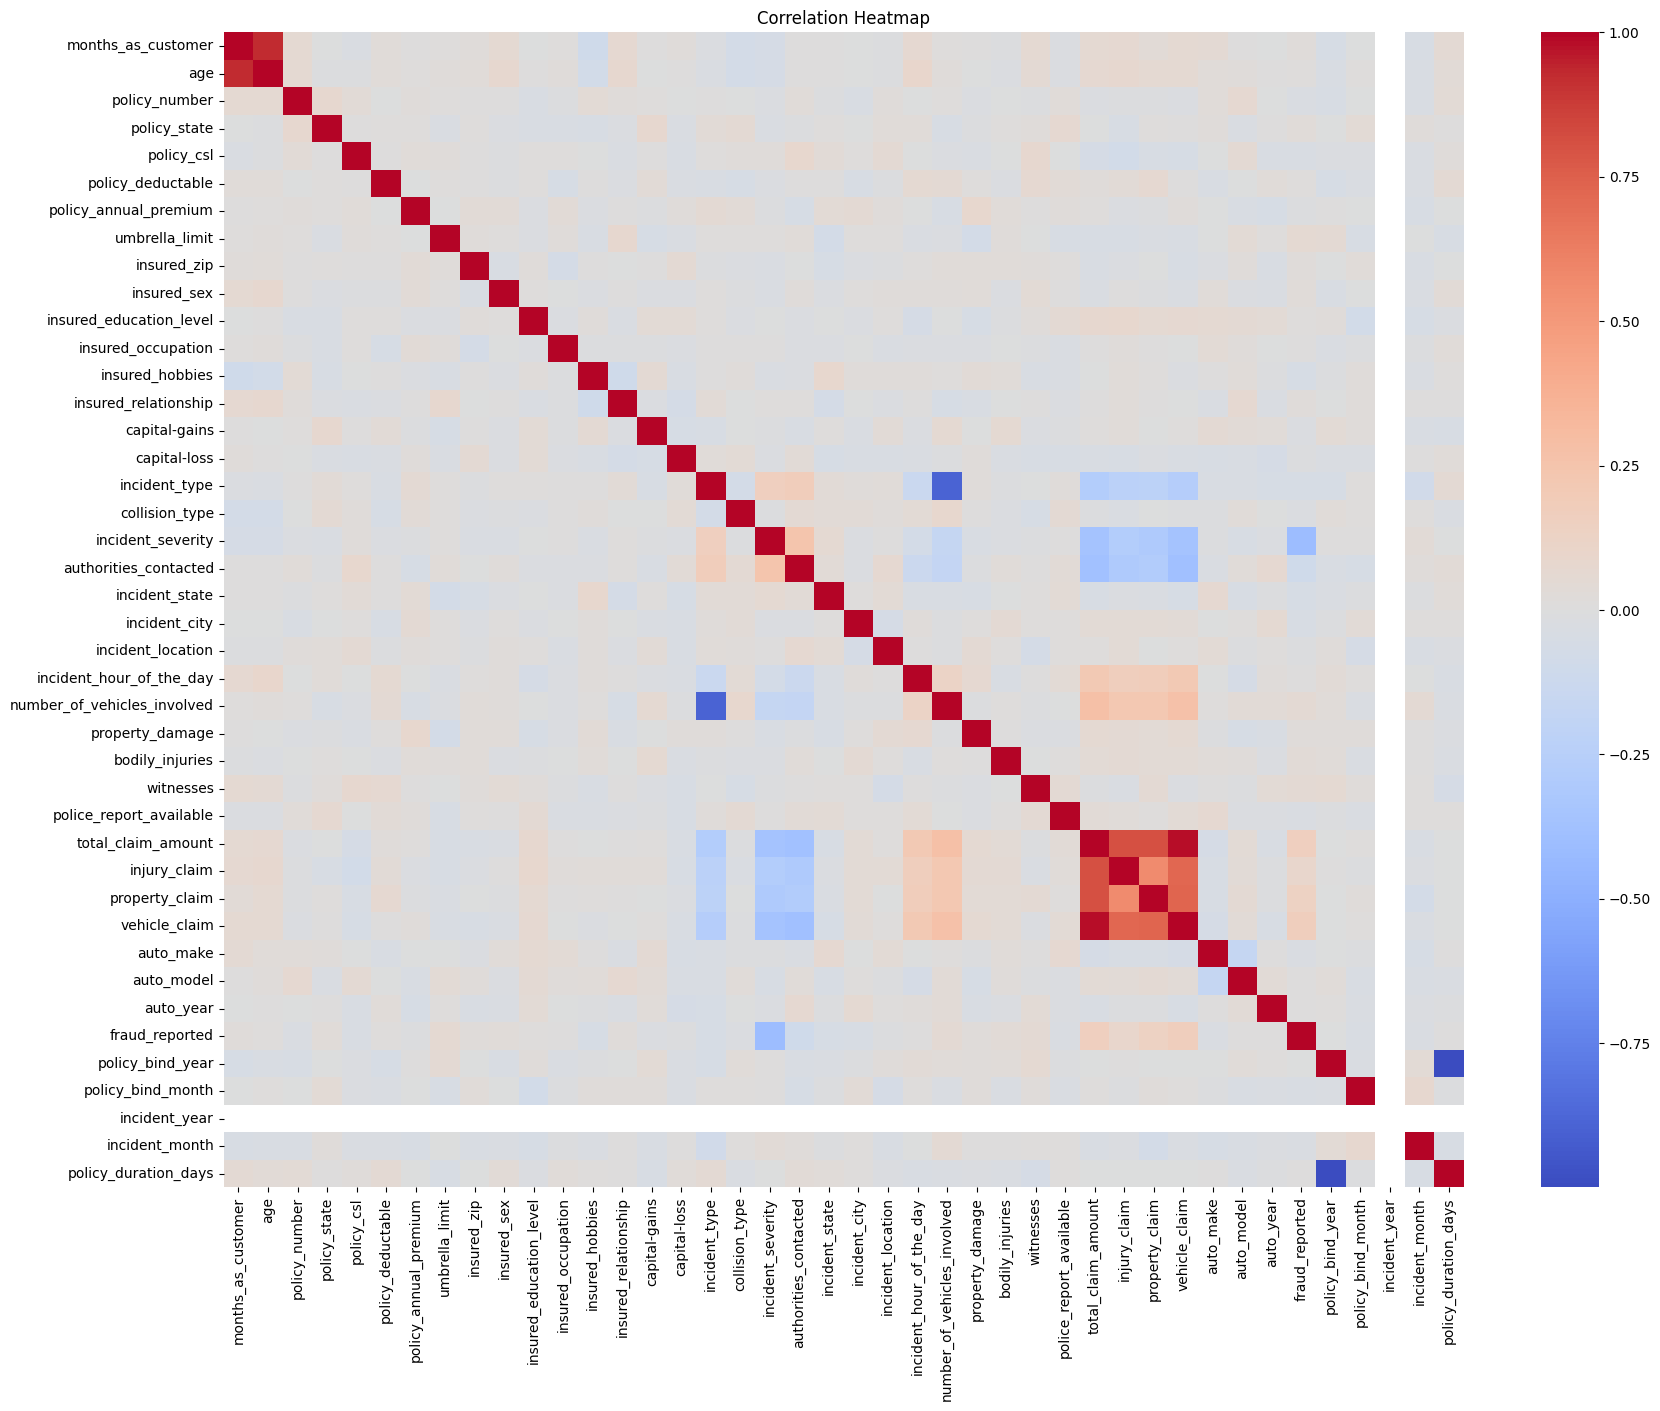

In [134]:
plt.figure(figsize=(20,15))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [135]:
corr_target = (
    df.corr()['fraud_reported']
    .sort_values(ascending=False)
)

print(corr_target)

fraud_reported                 1.000000
vehicle_claim                  0.170049
total_claim_amount             0.163651
property_claim                 0.137835
injury_claim                   0.090975
umbrella_limit                 0.058622
number_of_vehicles_involved    0.051839
witnesses                      0.049497
bodily_injuries                0.033877
insured_sex                    0.030873
policy_state                   0.029432
insured_relationship           0.021043
months_as_customer             0.020544
insured_zip                    0.019368
property_damage                0.017202
policy_deductable              0.014817
age                            0.012143
insured_education_level        0.008808
auto_year                      0.007928
incident_hour_of_the_day       0.004316
insured_occupation             0.001564
policy_duration_days           0.000930
auto_model                     0.000720
policy_bind_year              -0.000059
incident_location             -0.008832


In [136]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

incident_year


In [137]:
constant_cols = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_cols.append(col)

print(constant_cols)

['incident_year']


In [138]:
df.drop(
    constant_cols,
    axis=1,
    inplace=True
)

In [139]:
df.shape

(1000, 41)

In [140]:
X = df.drop(
    'fraud_reported',
    axis=1
)

y = df['fraud_reported']

In [141]:
print(X.shape)
print(y.shape)

(1000, 40)
(1000,)


In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [143]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 40)
(200, 40)
(800,)
(200,)


In [144]:
print(y_train.value_counts())

fraud_reported
0    602
1    198
Name: count, dtype: int64


(1204, 40)
(1204,)
fraud_reported
0    602
1    602
Name: count, dtype: int64


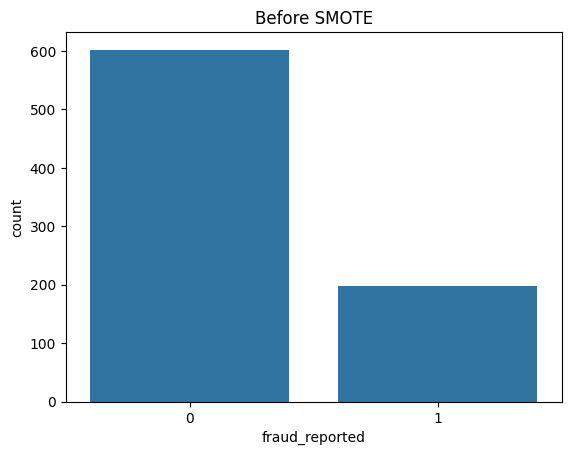

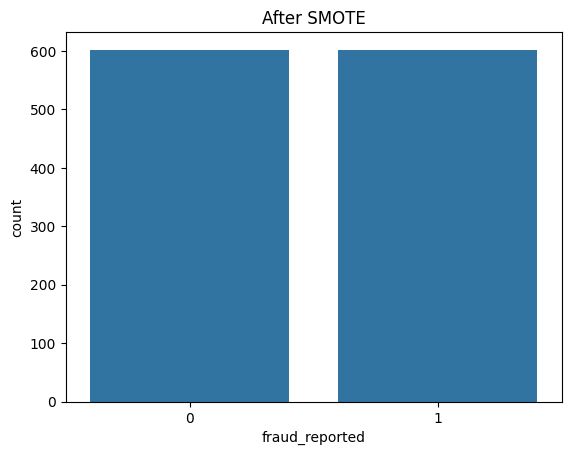

In [145]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train,
        y_train
    )
)

print(X_train_smote.shape)
print(y_train_smote.shape)

print(y_train_smote.value_counts())

sns.countplot(x=y_train)
plt.title("Before SMOTE")
plt.show()

sns.countplot(x=y_train_smote)
plt.title("After SMOTE")
plt.show()

In [146]:
X_train_smote.shape


(1204, 40)

In [147]:

y_train_smote.value_counts()

,count
fraud_reported,
0,602
1,602


In [148]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [149]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [150]:
lr.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [151]:
lr_pred = lr.predict(
    X_test
)

In [152]:
lr_prob = lr.predict_proba(
    X_test
)[:,1]

In [153]:
print("Accuracy:",
      accuracy_score(
          y_test,
          lr_pred
      ))

print("Precision:",
      precision_score(
          y_test,
          lr_pred
      ))

print("Recall:",
      recall_score(
          y_test,
          lr_pred
      ))

print("F1 Score:",
      f1_score(
          y_test,
          lr_pred
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          lr_prob
      ))

Accuracy: 0.545
Precision: 0.2980769230769231
Recall: 0.6326530612244898
F1 Score: 0.40522875816993464
ROC-AUC: 0.6146776591431274


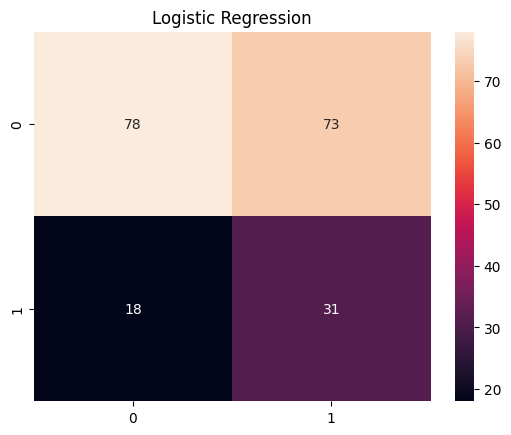

In [154]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression"
)

plt.show()

In [155]:
dt = DecisionTreeClassifier(
    random_state=42
)

In [156]:
dt.fit(
    X_train_smote,
    y_train_smote
)

DecisionTreeClassifier(random_state=42)

In [157]:
dt_pred = dt.predict(
    X_test
)

dt_prob = dt.predict_proba(
    X_test
)[:,1]

In [158]:
print("Accuracy:",
      accuracy_score(
          y_test,
          dt_pred
      ))

print("Precision:",
      precision_score(
          y_test,
          dt_pred
      ))

print("Recall:",
      recall_score(
          y_test,
          dt_pred
      ))

print("F1 Score:",
      f1_score(
          y_test,
          dt_pred
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          dt_prob
      ))

Accuracy: 0.71
Precision: 0.43283582089552236
Recall: 0.5918367346938775
F1 Score: 0.5
ROC-AUC: 0.6700905527774024


In [159]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [160]:
rf.fit(
    X_train_smote,
    y_train_smote
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [161]:
rf_pred = rf.predict(
    X_test
)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

In [162]:
print("Accuracy:",
      accuracy_score(
          y_test,
          rf_pred
      ))

print("Precision:",
      precision_score(
          y_test,
          rf_pred
      ))

print("Recall:",
      recall_score(
          y_test,
          rf_pred
      ))

print("F1 Score:",
      f1_score(
          y_test,
          rf_pred
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          rf_prob
      ))

Accuracy: 0.805
Precision: 0.6136363636363636
Recall: 0.5510204081632653
F1 Score: 0.5806451612903226
ROC-AUC: 0.8399107987565887


In [163]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [164]:
xgb.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [165]:
xgb_pred = xgb.predict(
    X_test
)

xgb_prob = xgb.predict_proba(
    X_test
)[:,1]

In [166]:
print("Accuracy:",
      accuracy_score(
          y_test,
          xgb_pred
      ))

print("Precision:",
      precision_score(
          y_test,
          xgb_pred
      ))

print("Recall:",
      recall_score(
          y_test,
          xgb_pred
      ))

print("F1 Score:",
      f1_score(
          y_test,
          xgb_pred
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          xgb_prob
      ))

Accuracy: 0.835
Precision: 0.6538461538461539
Recall: 0.6938775510204082
F1 Score: 0.6732673267326733
ROC-AUC: 0.8188944451952966


In [167]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

In [168]:
from sklearn.model_selection import GridSearchCV

In [169]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [170]:
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [171]:
grid_search.fit(
    X_train_smote,
    y_train_smote
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [172]:
best_xgb = grid_search.best_estimator_

In [173]:
best_pred = best_xgb.predict(
    X_test
)

best_prob = best_xgb.predict_proba(
    X_test
)[:,1]

In [174]:
print("Accuracy:",
      accuracy_score(
          y_test,
          best_pred
      ))

print("Precision:",
      precision_score(
          y_test,
          best_pred
      ))

print("Recall:",
      recall_score(
          y_test,
          best_pred
      ))

print("F1:",
      f1_score(
          y_test,
          best_pred
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          best_prob
      ))

Accuracy: 0.825
Precision: 0.6296296296296297
Recall: 0.6938775510204082
F1: 0.6601941747572816
ROC-AUC: 0.8265981889444519


In [175]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
0.8874923326869876


In [176]:
import shap

In [177]:
explainer = shap.TreeExplainer(
    best_xgb
)

In [178]:
shap_values = explainer.shap_values(
    X_test
)

In [179]:
print(shap_values.shape)

(200, 40)


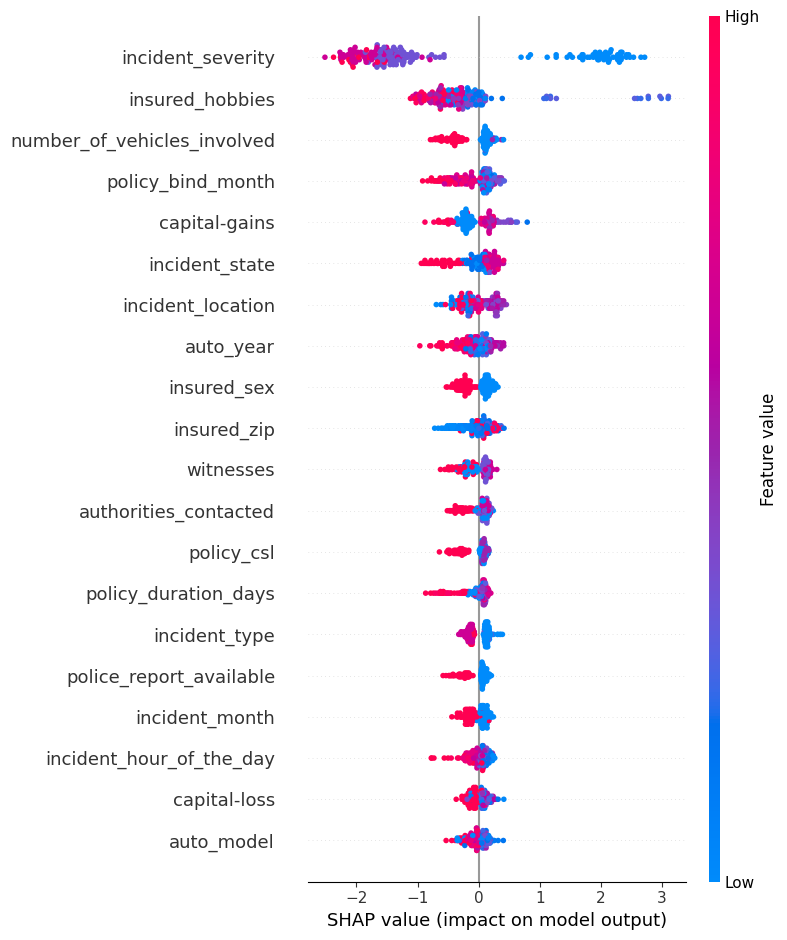

In [180]:
shap.summary_plot(
    shap_values,
    X_test
)

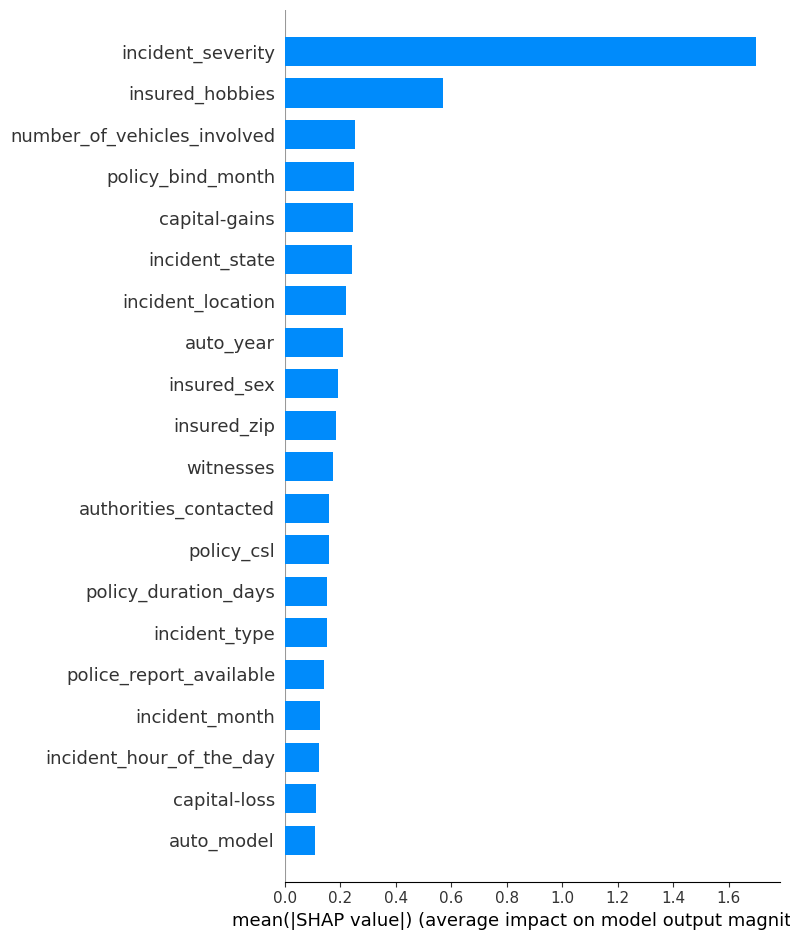

In [181]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

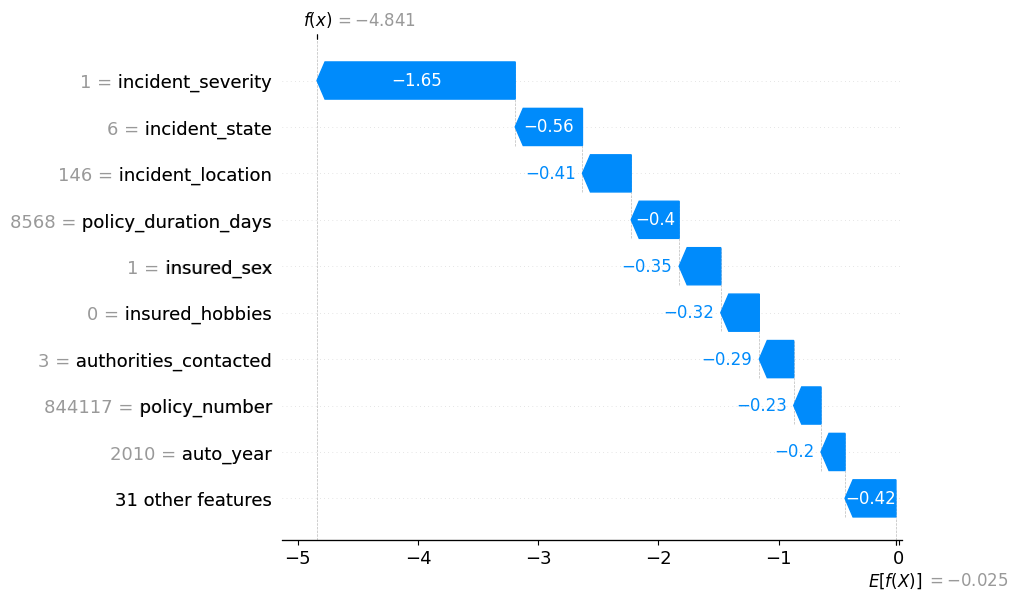

In [182]:
sample=0
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample],
        feature_names=X_test.columns
    )
)

In [183]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[sample],
    X_test.iloc[sample]
)

In [184]:
sample = 0

print("Actual Label:")
print(y_test.iloc[sample])

print("Prediction:")
print(best_xgb.predict(
    X_test.iloc[[sample]]
))

print("Probability:")
print(best_xgb.predict_proba(
    X_test.iloc[[sample]]
))

Actual Label:
0
Prediction:
[0]
Probability:
[[0.9921617  0.00783831]]


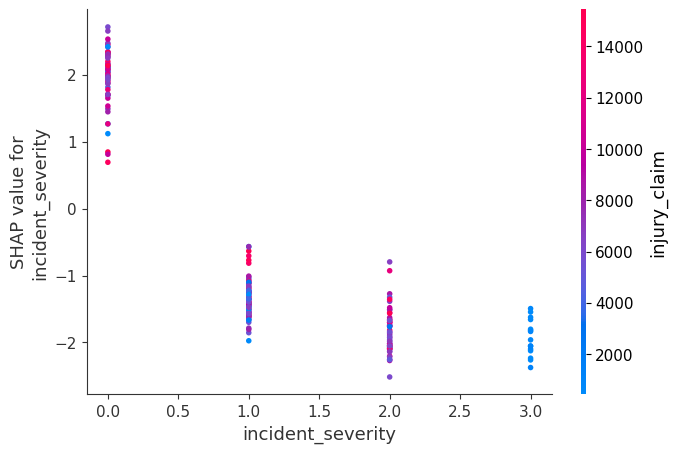

In [185]:
shap.dependence_plot(
    "incident_severity",
    shap_values,
    X_test
)

In [186]:
import joblib

joblib.dump(best_xgb, "insurance_fraud_model.pkl")

['insurance_fraud_model.pkl']

In [187]:
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [188]:
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [189]:
import os

print(os.listdir())

['.config', 'feature_names.pkl', 'label_encoders.pkl', 'insurance_fraud_model.pkl', 'insurance_claims.csv', 'sample_data']


In [191]:
df_deploy = df.copy()

missing_cols = [
    'collision_type',
    'authorities_contacted',
    'property_damage',
    'police_report_available'
]

for col in missing_cols:
    df_deploy[col].fillna(
        df_deploy[col].mode()[0],
        inplace=True
    )

In [192]:
df_deploy['fraud_reported'] = (
    df_deploy['fraud_reported']
    .map({
        'Y': 1,
        'N': 0
    })
)

In [193]:
df_deploy['policy_bind_date'] = pd.to_datetime(
    df_deploy['policy_bind_date']
)

df_deploy['incident_date'] = pd.to_datetime(
    df_deploy['incident_date']
)

KeyError: 'policy_bind_date'

In [194]:
df_deploy['policy_bind_year'] = (
    df_deploy['policy_bind_date'].dt.year
)

df_deploy['policy_bind_month'] = (
    df_deploy['policy_bind_date'].dt.month
)

df_deploy['incident_year'] = (
    df_deploy['incident_date'].dt.year
)

df_deploy['incident_month'] = (
    df_deploy['incident_date'].dt.month
)

df_deploy['policy_duration_days'] = (
    df_deploy['incident_date']
    - df_deploy['policy_bind_date']
).dt.days

KeyError: 'policy_bind_date'

In [ ]:
cols_to_drop = [
    'policy_bind_date',
    'incident_date',
    'policy_number',
    'insured_zip',
    'incident_location'
]

df_deploy.drop(
    cols_to_drop,
    axis=1,
    inplace=True
)

print(df_deploy.shape)

In [ ]:
label_encoders = {}

categorical_cols = (
    df_deploy
    .select_dtypes(include='object')
    .columns
)

for col in categorical_cols:

    le = LabelEncoder()

    df_deploy[col] = (
        le.fit_transform(
            df_deploy[col]
        )
    )

    label_encoders[col] = le

In [ ]:
X = df_deploy.drop(
    'fraud_reported',
    axis=1
)

y = df_deploy['fraud_reported']

print(X.shape)
print(y.shape)

In [ ]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )
)

In [ ]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train,
        y_train
    )
)

print(y_train_smote.value_counts())

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(
    X_train_smote,
    y_train_smote
)

best_xgb = grid_search.best_estimator_

joblib.dump(
    best_xgb,
    'insurance_fraud_model.pkl'
)

In [ ]:
joblib.dump(
    label_encoders,
    'label_encoders.pkl'
)

In [ ]:
joblib.dump(
    X.columns.tolist(),
    'feature_names.pkl'
)

In [ ]:
import os

print(os.listdir())

In [ ]:
from google.colab import files

files.download(
    'insurance_fraud_model.pkl'
)

files.download(
    'label_encoders.pkl'
)

In [ ]:
!pip install streamlit

In [ ]:
!pip install streamlit pyngrok

In [ ]:
import os

print(
    os.path.exists(
        'insurance_fraud_model.pkl'
    )
)

print(
    os.path.exists(
        'label_encoders.pkl'
    )
)

print(
    os.path.exists(
        'feature_names.pkl'
    )
)

In [ ]:
import joblib

joblib.dump(best_xgb, "insurance_fraud_model.pkl")

In [ ]:
import xgboost
print(xgboost.__version__)